# Music Genre Classification

This notebook compares several multiclass classification models for predicting a song's genre from its audio characteristics. The original nine-feature experiments are retained as a baseline, followed by a separate expanded-feature CatBoost experiment.


## Imports

In [2]:
import numpy as np
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from xgboost import XGBClassifier
from catboost import CatBoostClassifier


In [3]:
data = pd.read_csv("music_genre.csv")
data.head()


,instance_id,artist_name,track_name,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,obtained_date,valence,music_genre
0,32894.0,Röyksopp,Röyksopp's Night Out,27.0,0.00468,0.652,-1.0,0.941,0.79200,A#,0.115,-5.201,Minor,0.0748,100.889,4-Apr,0.759,Electronic
1,46652.0,Thievery Corporation,The Shining Path,31.0,0.01270,0.622,218293.0,0.890,0.95000,D,0.124,-7.043,Minor,0.0300,115.00200000000001,4-Apr,0.531,Electronic
2,30097.0,Dillon Francis,Hurricane,28.0,0.00306,0.620,215613.0,0.755,0.01180,G#,0.534,-4.617,Major,0.0345,127.994,4-Apr,0.333,Electronic
3,62177.0,Dubloadz,Nitro,34.0,0.02540,0.774,166875.0,0.700,0.00253,C#,0.157,-4.498,Major,0.2390,128.014,4-Apr,0.270,Electronic
4,24907.0,What So Not,Divide & Conquer,32.0,0.00465,0.638,222369.0,0.587,0.90900,F#,0.157,-6.266,Major,0.0413,145.036,4-Apr,0.323,Electronic


## Data Cleaning 

The dataset is already relatively clean. The checks below confirm the missing values, target labels, and data types before modelling.


In [3]:
data.isnull().sum()


instance_id         5
artist_name         5
track_name          5
popularity          5
acousticness        5
danceability        5
duration_ms         5
energy              5
instrumentalness    5
key                 5
liveness            5
loudness            5
mode                5
speechiness         5
tempo               5
obtained_date       5
valence             5
music_genre         5
dtype: int64

In [4]:
data['music_genre'].unique()


<ArrowStringArray>
[ 'Electronic',       'Anime',           nan,        'Jazz', 'Alternative',
     'Country',         'Rap',       'Blues',        'Rock',   'Classical',
     'Hip-Hop']
Length: 11, dtype: str

In [5]:
data = data.dropna()


In [6]:
data.isnull().sum()


instance_id         0
artist_name         0
track_name          0
popularity          0
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
speechiness         0
tempo               0
obtained_date       0
valence             0
music_genre         0
dtype: int64

In [7]:
print("Actual NaNs:", data["music_genre"].isna().sum())

print(
    "Text 'nan' values:",
    data["music_genre"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("nan")
    .sum()
)


Actual NaNs: 0
Text 'nan' values: 0


In [8]:
feature_columns = [
    "acousticness",
    "danceability",
    "energy",
    "instrumentalness",
    "liveness",
    "loudness",
    "speechiness",
    "tempo",
    "valence"
]


In [9]:
columns_to_keep = feature_columns + ["music_genre"]

model_df = data[columns_to_keep].copy()

# Replace question marks with missing values
model_df[feature_columns] = model_df[feature_columns].replace("?", pd.NA)

# Convert every feature column to numbers
for column in feature_columns:
    model_df[column] = pd.to_numeric(
        model_df[column],
        errors="coerce"
    )

# Remove records containing missing model values
model_df = model_df.dropna(subset=columns_to_keep)

# Round all numerical columns
model_df[feature_columns] = model_df[feature_columns].round(3)

# Export with exactly three decimal places
model_df.to_csv(
    "music_genre_model_data.csv",
    index=False,
    float_format="%.3f"
)


## Random Forest

Random Forest is used as the baseline model because it supports multiclass classification and can capture non-linear relationships between the audio features. This first experiment deliberately uses the original nine-feature set so that later models can be compared fairly.


In [10]:
X = model_df[feature_columns] # contains model inputs 

y = model_df["music_genre"] # what model will predict 

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size = 0.2, 
    random_state = 42, 
    stratify = y #ensure same proprtion of each genre in both sets 
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))
print("\nTraining genre counts:")
print(y_train.value_counts())


Training records: 36016
Testing records: 9004

Training genre counts:
music_genre
Rock           3649
Jazz           3617
Hip-Hop        3616
Rap            3603
Classical      3600
Anime          3597
Alternative    3596
Country        3589
Blues          3576
Electronic     3573
Name: count, dtype: int64


In [11]:
random_forest = RandomForestClassifier(
    n_estimators = 200, # 200 trees
    random_state = 42, 
    n_jobs = -1
)

random_forest.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [12]:
y_pred = random_forest.predict(X_test)

accuracy = accuracy_score(y_test, y_pred) #overall proportion predicted correctly
macro_f1 = f1_score(y_test, y_pred, average="macro") #calculates performance for every genre equally then averages it 

print(f"Accuracy: {accuracy:.3f}")
print(f"Macro F1-score: {macro_f1:.3f}")

print("\nClassification report:") # shows precision, recall and f1 score for each genre 
print(classification_report(y_test, y_pred))


Accuracy: 0.401
Macro F1-score: 0.394

Classification report:
              precision    recall  f1-score   support

 Alternative       0.23      0.19      0.21       899
       Anime       0.48      0.37      0.42       900
       Blues       0.37      0.35      0.36       894
   Classical       0.77      0.86      0.82       900
     Country       0.40      0.50      0.45       897
  Electronic       0.55      0.58      0.57       893
     Hip-Hop       0.28      0.34      0.30       904
        Jazz       0.44      0.47      0.45       904
         Rap       0.23      0.24      0.23       901
        Rock       0.17      0.12      0.14       912

    accuracy                           0.40      9004
   macro avg       0.39      0.40      0.39      9004
weighted avg       0.39      0.40      0.39      9004



The baseline results suggest substantial overlap between several genres. The confusion matrix below is used as a diagnostic tool to identify the genre pairs the model finds hardest to separate.


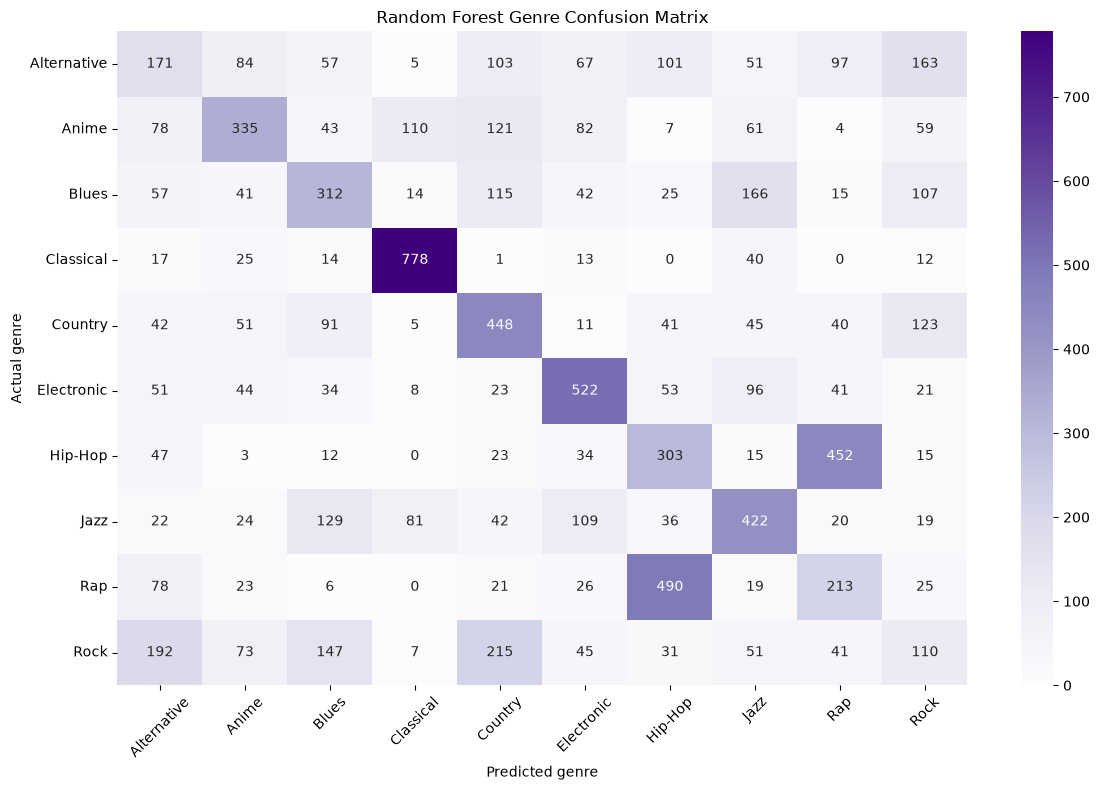

In [13]:
labels = sorted(y_test.unique())

matrix = confusion_matrix(
    y_test, 
    y_pred, 
    labels = labels 
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    matrix, 
    annot = True, 
    fmt = "d",
    cmap = "Purples", 
    xticklabels = labels,
    yticklabels = labels
)

plt.title("Random Forest Genre Confusion Matrix")
plt.xlabel("Predicted genre")
plt.ylabel("Actual genre")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


The largest errors occur between genres with related or overlapping audio profiles, particularly Hip-Hop and Rap. Rock is also frequently confused with Blues and Country, so their feature distributions are examined below.


In [14]:
genres_to_compare = ["Rock", "Blues", "Country"]

genre_comparison = (
    model_df[
        model_df["music_genre"].isin(genres_to_compare)
    ]
    .groupby("music_genre")[feature_columns]
    .mean()
    .round(3)
)

genre_comparison


,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
music_genre,,,,,,,,,
Blues,0.315,0.528,0.611,0.093,0.234,-8.980,0.062,121.380,0.579
Country,0.269,0.577,0.638,0.005,0.186,-7.306,0.049,123.784,0.537
Rock,0.191,0.539,0.688,0.054,0.186,-7.222,0.053,122.670,0.522


In [15]:
genre_medians = (
    model_df[
        model_df["music_genre"].isin(genres_to_compare)
    ]
    .groupby("music_genre")[feature_columns]
    .median()
    .round(3)
)

genre_medians


,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
music_genre,,,,,,,,,
Blues,0.209,0.528,0.632,0.001,0.138,-8.411,0.043,118.372,0.587
Country,0.176,0.581,0.669,0.000,0.128,-6.538,0.034,123.042,0.527
Rock,0.071,0.546,0.723,0.000,0.126,-6.464,0.039,121.104,0.518


The mean and median values are similar across Blues, Country, and Rock. Box plots provide a clearer view of the overlap across the full distributions rather than only comparing their central values.


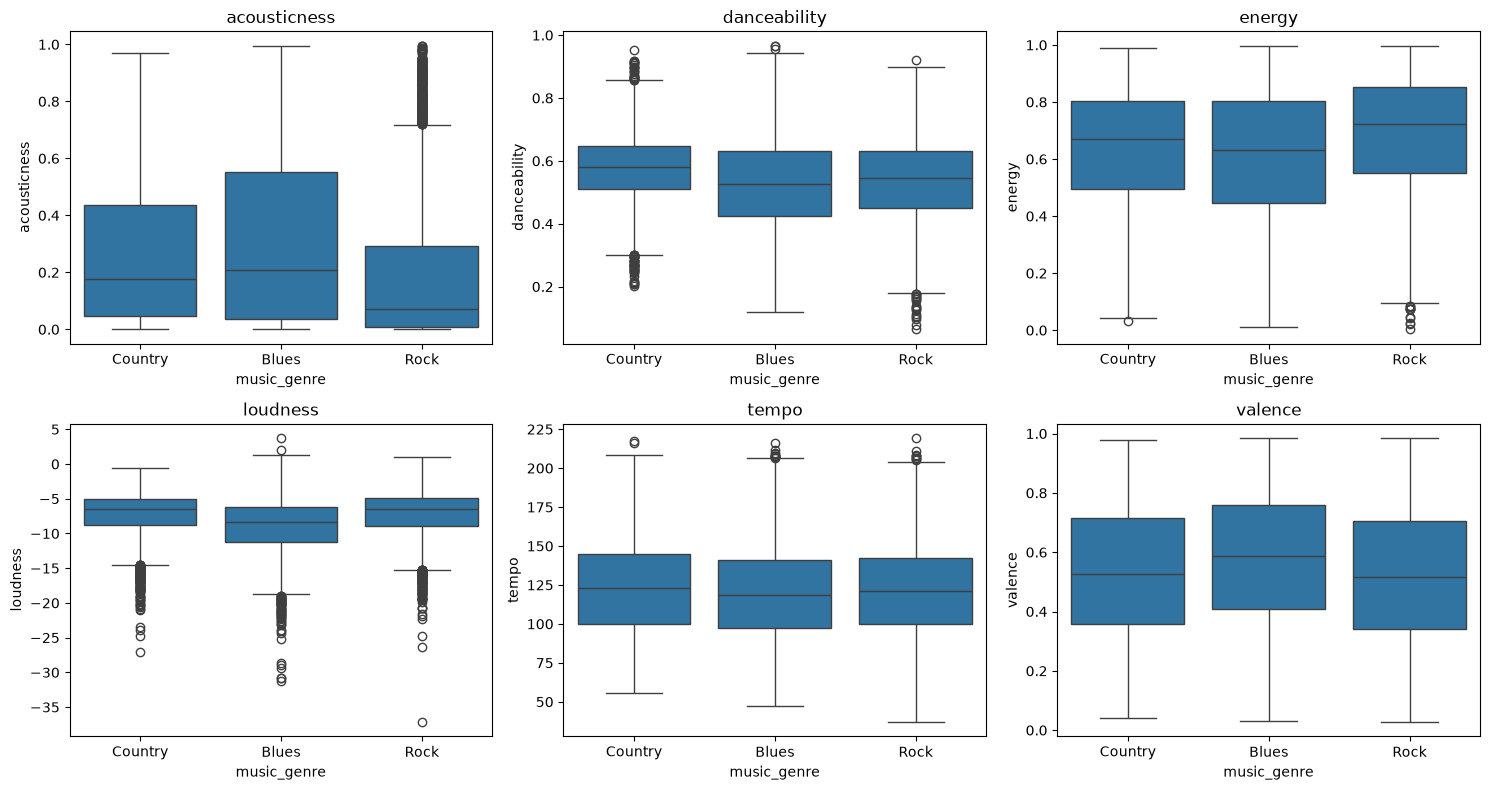

In [16]:
comparison_df = model_df[
    model_df["music_genre"].isin(["Blues", "Country", "Rock"])
]

features_to_plot = [
    "acousticness", 
    "danceability", 
    "energy", 
    "loudness", 
    "tempo", 
    "valence"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for feature, ax in zip(features_to_plot, axes.flatten()): 
    sns.boxplot(
        data = comparison_df, 
        x = "music_genre", 
        y = feature, 
        ax = ax 
    )
    ax.set_title(feature)

plt.tight_layout()
plt.show()


The distributions confirm that the original nine numerical features do not completely separate these genres. The next experiments test whether boosting models can capture more complex decision boundaries.


## XGBoost

XGBoost is tested using the same training and test data as the Random Forest. Keeping the feature set and split unchanged ensures that any performance difference is caused by the model rather than different data.


In [17]:
# Convert genre names into numbers
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Create and train the model
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)

xgb_model.fit(X_train, y_train_encoded)

# Make predictions
y_pred_encoded = xgb_model.predict(X_test)
y_pred = label_encoder.inverse_transform(y_pred_encoded)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("\nClassification report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.419

Classification report:
              precision    recall  f1-score   support

 Alternative       0.26      0.21      0.23       899
       Anime       0.48      0.39      0.43       900
       Blues       0.39      0.36      0.38       894
   Classical       0.79      0.84      0.81       900
     Country       0.40      0.52      0.45       897
  Electronic       0.58      0.58      0.58       893
     Hip-Hop       0.31      0.37      0.34       904
        Jazz       0.44      0.50      0.47       904
         Rap       0.27      0.28      0.28       901
        Rock       0.19      0.13      0.16       912

    accuracy                           0.42      9004
   macro avg       0.41      0.42      0.41      9004
weighted avg       0.41      0.42      0.41      9004



In [18]:
tuned_xgb_model = XGBClassifier(
    n_estimators=600,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=2,
    random_state=42,
    eval_metric="mlogloss",
    n_jobs=-1
)

tuned_xgb_model.fit(X_train, y_train_encoded)

y_pred_encoded = tuned_xgb_model.predict(X_test)
y_pred_tuned = label_encoder.inverse_transform(y_pred_encoded)

print("Accuracy:", round(accuracy_score(y_test, y_pred_tuned), 3))
print("Macro F1:", round(f1_score(y_test, y_pred_tuned, average="macro"), 3))
print("\nClassification report:")
print(classification_report(y_test, y_pred_tuned))


Accuracy: 0.412
Macro F1: 0.407

Classification report:
              precision    recall  f1-score   support

 Alternative       0.23      0.20      0.22       899
       Anime       0.51      0.41      0.45       900
       Blues       0.40      0.37      0.39       894
   Classical       0.79      0.84      0.81       900
     Country       0.41      0.52      0.46       897
  Electronic       0.57      0.56      0.57       893
     Hip-Hop       0.30      0.36      0.32       904
        Jazz       0.44      0.48      0.46       904
         Rap       0.25      0.26      0.25       901
        Rock       0.17      0.13      0.14       912

    accuracy                           0.41      9004
   macro avg       0.41      0.41      0.41      9004
weighted avg       0.41      0.41      0.41      9004



In [19]:
cat_model = CatBoostClassifier(
    iterations=500,
    depth=8,
    learning_rate=0.1,
    loss_function="MultiClass",
    random_seed=42,
    verbose=False
)

cat_model.fit(X_train, y_train)
y_pred_cat = cat_model.predict(X_test).flatten()

print("Accuracy:", round(accuracy_score(y_test, y_pred_cat), 3))
print("Macro F1:", round(f1_score(y_test, y_pred_cat, average="macro"), 3))
print("\nClassification report:")
print(classification_report(y_test, y_pred_cat))


Accuracy: 0.428
Macro F1: 0.421

Classification report:
              precision    recall  f1-score   support

 Alternative       0.29      0.24      0.26       899
       Anime       0.48      0.39      0.43       900
       Blues       0.41      0.40      0.41       894
   Classical       0.79      0.86      0.82       900
     Country       0.41      0.53      0.46       897
  Electronic       0.57      0.58      0.57       893
     Hip-Hop       0.32      0.38      0.35       904
        Jazz       0.43      0.47      0.45       904
         Rap       0.28      0.28      0.28       901
        Rock       0.21      0.15      0.18       912

    accuracy                           0.43      9004
   macro avg       0.42      0.43      0.42      9004
weighted avg       0.42      0.43      0.42      9004



## CatBoost optimisation using the original features

The original CatBoost model produced the strongest result so far. A validation set and early stopping are now used to estimate an appropriate number of boosting iterations without repeatedly tuning against the test set.


In [20]:
X_train_final, X_validation, y_train_final, y_validation = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

optimised_cat_model = CatBoostClassifier(
    iterations=800,
    depth=7,
    learning_rate=0.05,
    loss_function="MultiClass",
    eval_metric="MultiClass",
    l2_leaf_reg=5,
    random_strength=1,
    random_seed=42,
    thread_count=-1, 
    verbose=100
)

optimised_cat_model.fit(
    X_train_final,
    y_train_final,
    eval_set=(X_validation, y_validation),
    early_stopping_rounds=50,
)

best_iterations = optimised_cat_model.get_best_iteration() + 1
print("Best number of iterations:", best_iterations)


0:	learn: 2.2411016	test: 2.2428199	best: 2.2428199 (0)	total: 113ms	remaining: 1m 30s
100:	learn: 1.4508101	test: 1.5006768	best: 1.5006768 (100)	total: 7.58s	remaining: 52.4s
200:	learn: 1.3775091	test: 1.4598276	best: 1.4598276 (200)	total: 14.5s	remaining: 43.2s
300:	learn: 1.3296383	test: 1.4442139	best: 1.4442139 (300)	total: 21.3s	remaining: 35.3s
400:	learn: 1.2905884	test: 1.4369566	best: 1.4369566 (400)	total: 28.2s	remaining: 28.1s
500:	learn: 1.2558949	test: 1.4335715	best: 1.4334968 (499)	total: 35.8s	remaining: 21.4s
600:	learn: 1.2237566	test: 1.4321048	best: 1.4320034 (594)	total: 42.5s	remaining: 14.1s
700:	learn: 1.1922215	test: 1.4317930	best: 1.4314756 (657)	total: 49.1s	remaining: 6.94s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1.431475567
bestIteration = 657

Shrink model to first 658 iterations.
Best number of iterations: 658


The selected iteration count is used to retrain CatBoost on the complete original training set. The untouched test set is then used once for the final evaluation of this version.


In [21]:
final_cat_model = CatBoostClassifier(
    iterations=best_iterations,
    depth=8,
    learning_rate=0.05,
    loss_function="MultiClass",
    l2_leaf_reg=5,
    random_strength=1,
    random_seed=42,
    verbose=False
)

final_cat_model.fit(X_train, y_train)
y_pred_final = final_cat_model.predict(X_test).flatten()

print("Final accuracy:", round(accuracy_score(y_test, y_pred_final), 3))
print("Final macro F1:", round(f1_score(y_test, y_pred_final, average="macro"), 3))
print("\nClassification report:")
print(classification_report(y_test, y_pred_final))


Final accuracy: 0.437
Final macro F1: 0.429

Classification report:
              precision    recall  f1-score   support

 Alternative       0.30      0.23      0.26       899
       Anime       0.48      0.40      0.44       900
       Blues       0.41      0.40      0.41       894
   Classical       0.79      0.85      0.82       900
     Country       0.40      0.54      0.46       897
  Electronic       0.56      0.58      0.57       893
     Hip-Hop       0.36      0.44      0.40       904
        Jazz       0.44      0.49      0.47       904
         Rap       0.31      0.30      0.31       901
        Rock       0.22      0.14      0.17       912

    accuracy                           0.44      9004
   macro avg       0.43      0.44      0.43      9004
weighted avg       0.43      0.44      0.43      9004



## Expanded feature set

The earlier experiments are intentionally left unchanged. This new dataset adds `popularity`, `duration_ms`, `key`, and `mode` so its result can be compared with the original nine-feature models.

Invalid tempo values and the `-1` duration placeholder are treated as missing data. Numerical gaps are filled with the training-set median later in the workflow, which retains more observations and prevents information from the test set leaking into preprocessing.


In [22]:
expanded_numerical_features = [
    "popularity",
    "acousticness",
    "danceability",
    "duration_ms",
    "energy",
    "instrumentalness",
    "liveness",
    "loudness",
    "speechiness",
    "tempo",
    "valence"
]

expanded_categorical_features = ["key", "mode"]
expanded_feature_columns = expanded_numerical_features + expanded_categorical_features

expanded_model_df = data[expanded_feature_columns + ["music_genre"]].copy()
expanded_model_df = expanded_model_df.replace("?", np.nan)

for column in expanded_numerical_features:
    expanded_model_df[column] = pd.to_numeric(
        expanded_model_df[column],
        errors="coerce"
    )

expanded_model_df["duration_ms"] = expanded_model_df["duration_ms"].replace(-1, np.nan)
expanded_model_df = expanded_model_df.dropna(subset=["music_genre"])

for column in expanded_categorical_features:
    expanded_model_df[column] = (
        expanded_model_df[column]
        .fillna("Unknown")
        .astype(str)
    )

print("Records available:", len(expanded_model_df))
expanded_model_df.head()


Records available: 50000


,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,key,mode,music_genre
0,27.0,0.00468,0.652,NaN,0.941,0.79200,0.115,-5.201,0.0748,100.889,0.759,A#,Minor,Electronic
1,31.0,0.01270,0.622,218293.0,0.890,0.95000,0.124,-7.043,0.0300,115.002,0.531,D,Minor,Electronic
2,28.0,0.00306,0.620,215613.0,0.755,0.01180,0.534,-4.617,0.0345,127.994,0.333,G#,Major,Electronic
3,34.0,0.02540,0.774,166875.0,0.700,0.00253,0.157,-4.498,0.2390,128.014,0.270,C#,Major,Electronic
4,32.0,0.00465,0.638,222369.0,0.587,0.90900,0.157,-6.266,0.0413,145.036,0.323,F#,Major,Electronic


### Leakage-safe train, validation, and test split

The same 80:20 stratified split is used for comparability. The training portion is split again to create a validation set for early stopping. Numerical medians are calculated only from the training subset and then applied to validation and test data.


In [23]:
X_expanded = expanded_model_df[expanded_feature_columns].copy()
y_expanded = expanded_model_df["music_genre"].copy()

X_train_expanded, X_test_expanded, y_train_expanded, y_test_expanded = train_test_split(
    X_expanded,
    y_expanded,
    test_size=0.2,
    random_state=42,
    stratify=y_expanded
)

X_train_expanded, X_validation_expanded, y_train_expanded, y_validation_expanded = train_test_split(
    X_train_expanded,
    y_train_expanded,
    test_size=0.2,
    random_state=42,
    stratify=y_train_expanded
)

training_medians = X_train_expanded[expanded_numerical_features].median()

for frame in [X_train_expanded, X_validation_expanded, X_test_expanded]:
    frame[expanded_numerical_features] = frame[expanded_numerical_features].fillna(training_medians)

print("Training records:", len(X_train_expanded))
print("Validation records:", len(X_validation_expanded))
print("Testing records:", len(X_test_expanded))


Training records: 32000
Validation records: 8000
Testing records: 10000


### Expanded-feature CatBoost model

CatBoost can process `key` and `mode` directly as categorical variables. Early stopping keeps the best validation iteration and reduces unnecessary training.


In [24]:
expanded_cat_model = CatBoostClassifier(
    iterations=800,
    depth=7,
    learning_rate=0.05,
    loss_function="MultiClass",
    eval_metric="MultiClass",
    l2_leaf_reg=5,
    random_strength=1,
    random_seed=42,
    thread_count=-1, 
    verbose=100
)

expanded_cat_model.fit(
    X_train_expanded,
    y_train_expanded,
    cat_features=expanded_categorical_features,
    eval_set=(X_validation_expanded, y_validation_expanded),
    early_stopping_rounds=50
)

expanded_best_iterations = expanded_cat_model.get_best_iteration() + 1
print("Best number of iterations:", expanded_best_iterations)


0:	learn: 2.2036219	test: 2.2051659	best: 2.2051659 (0)	total: 406ms	remaining: 5m 24s
100:	learn: 1.1001268	test: 1.1301421	best: 1.1301421 (100)	total: 41.5s	remaining: 4m 47s
200:	learn: 1.0084682	test: 1.0680039	best: 1.0680039 (200)	total: 1m 17s	remaining: 3m 51s
300:	learn: 0.9549501	test: 1.0393307	best: 1.0393307 (300)	total: 1m 54s	remaining: 3m 9s
400:	learn: 0.9182228	test: 1.0249425	best: 1.0249425 (400)	total: 2m 29s	remaining: 2m 29s
500:	learn: 0.8882772	test: 1.0182226	best: 1.0182226 (500)	total: 3m 3s	remaining: 1m 49s
600:	learn: 0.8615636	test: 1.0136639	best: 1.0136639 (600)	total: 3m 38s	remaining: 1m 12s
700:	learn: 0.8370514	test: 1.0113816	best: 1.0113816 (700)	total: 4m 15s	remaining: 36.1s
799:	learn: 0.8126152	test: 1.0096483	best: 1.0096483 (799)	total: 4m 53s	remaining: 0us

bestTest = 1.009648305
bestIteration = 799

Best number of iterations: 800


The model below is retrained using both the training and validation records, then evaluated on the untouched expanded-feature test set.


In [26]:
X_full_train_expanded = pd.concat(
    [X_train_expanded, X_validation_expanded],
    axis=0
)
y_full_train_expanded = pd.concat(
    [y_train_expanded, y_validation_expanded],
    axis=0
)

final_expanded_cat_model = CatBoostClassifier(
    iterations=expanded_best_iterations,
    depth=7,
    learning_rate=0.05,
    loss_function="MultiClass",
    l2_leaf_reg=5,
    random_strength=1,
    random_seed=42,
    verbose=False
)

final_expanded_cat_model.fit(
    X_full_train_expanded,
    y_full_train_expanded,
    cat_features=expanded_categorical_features
)

y_pred_expanded = final_expanded_cat_model.predict(X_test_expanded).flatten()

expanded_accuracy = accuracy_score(y_test_expanded, y_pred_expanded)
expanded_macro_f1 = f1_score(y_test_expanded, y_pred_expanded, average="macro")

print("Expanded-feature accuracy:", round(expanded_accuracy, 3))
print("Expanded-feature macro F1:", round(expanded_macro_f1, 3))
print("\nClassification report:")
print(classification_report(y_test_expanded, y_pred_expanded))


Expanded-feature accuracy: 0.607
Expanded-feature macro F1: 0.607

Classification report:
              precision    recall  f1-score   support

 Alternative       0.51      0.42      0.46      1000
       Anime       0.83      0.77      0.80      1000
       Blues       0.64      0.59      0.62      1000
   Classical       0.88      0.84      0.86      1000
     Country       0.62      0.62      0.62      1000
  Electronic       0.68      0.63      0.65      1000
     Hip-Hop       0.43      0.42      0.42      1000
        Jazz       0.57      0.59      0.58      1000
         Rap       0.42      0.44      0.43      1000
        Rock       0.54      0.74      0.62      1000

    accuracy                           0.61     10000
   macro avg       0.61      0.61      0.61     10000
weighted avg       0.61      0.61      0.61     10000



## Export the final model

The expanded-feature CatBoost model is exported after training so the Streamlit application can load it and make predictions without retraining it. The preprocessing information is saved separately to ensure that future song data uses the same feature order and missing-value medians as the training data.


In [33]:
# Save the trained CatBoost model
final_expanded_cat_model.save_model("expanded_genre_model.cbm")

# Save the preprocessing information required by the Streamlit app
model_information = {
    "numerical_features": expanded_numerical_features,
    "categorical_features": expanded_categorical_features,
    "feature_columns": expanded_feature_columns,
    "training_medians": training_medians,
    "genre_classes": list(final_expanded_cat_model.classes_)
}

joblib.dump(
    model_information,
    "genre_model_information.pkl"
)

print("Model exported as expanded_genre_model.cbm")
print("Preprocessing information exported as genre_model_information.pkl")


Model exported as expanded_genre_model.cbm
Preprocessing information exported as genre_model_information.pkl


## Return the user's top three predicted genres

CatBoost calculates a probability for every genre. When the user provides multiple favourite songs, the function below averages their genre probabilities to create one overall listening profile. It then returns the three genres with the highest average probabilities.

The input DataFrame must contain the expanded features in the same order used during training.


In [35]:
def predict_top_genres(model, user_song_features, top_n=3):
    # Predict a genre probability distribution for each selected song
    song_probabilities = model.predict_proba(user_song_features)

    # Combine the songs into one overall user profile
    average_probabilities = song_probabilities.mean(axis=0)

    # Find the genres with the highest average probabilities
    top_indices = np.argsort(average_probabilities)[-top_n:][::-1]
    genre_names = np.asarray(model.classes_)

    return pd.DataFrame({
        "Predicted genre": genre_names[top_indices],
        "Probability": average_probabilities[top_indices]
    })


## Model comparison

After running the new cells, compare both accuracy and macro F1. Accuracy measures the overall proportion of correct predictions, while macro F1 gives every genre equal importance and is therefore the main optimisation metric.


In [36]:
model_comparison = pd.DataFrame({
    "Model": [
        "Random Forest (original features)",
        "XGBoost (original features)",
        "Tuned XGBoost (original features)",
        "CatBoost (original features)",
        "Optimised CatBoost (original features)",
        "CatBoost (expanded features)"
    ],
    "Accuracy": [0.401, 0.419, 0.412, 0.428, accuracy_score(y_test, y_pred_final), expanded_accuracy],
    "Macro F1": [0.394, 0.410, 0.407, 0.421, f1_score(y_test, y_pred_final, average="macro"), expanded_macro_f1]
})

model_comparison.round(3)


,Model,Accuracy,Macro F1
0,Random Forest (original features),0.401,0.394
1,XGBoost (original features),0.419,0.410
2,Tuned XGBoost (original features),0.412,0.407
3,CatBoost (original features),0.428,0.421
4,Optimised CatBoost (original features),0.437,0.429
5,CatBoost (expanded features),0.607,0.607


The expanded feature CatBoost model was selected as the final model because it achieved the strongest overall performance, with an accuracy and macro F1 score of 0.607. 

This considerably outperformed the optimised CatBoost model using the original features, which achieved an accuracy of 0.437 and a macro F1 score of 0.429. 

The results show that adding `popularity`, `duration`, `key`, and `mode` provided the model with useful information for disinguising between genres. 

In [4]:
data['key'].unique()

<ArrowStringArray>
['A#', 'D', 'G#', 'C#', 'F#', 'B', 'G', 'F', 'A', 'C', 'E', 'D#', nan]
Length: 13, dtype: str